# 13) Mammoth/CUES binary time-series comparison

This notebook performs **comparison only**. All RGB selection, spatial averaging, ERA5 matching, updated-rule classification, CUES cleaning, clear-sky calculation, and $k_t$ classification are completed externally by `build_mammoth_cues_binary_timeseries.py`.

Inputs are two finished binary time series:

- RGB: `0=clear`, `1=cloud`, using every available raw Mammoth RGB timestamp.
- CUES shortwave: `1=cloud` for $k_t<0.55$ and `0=clear` for $k_t>0.85$; the interval from 0.55 through 0.85 is excluded as ambiguous.

## 1. Load the two independently processed binary time series

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             balanced_accuracy_score, cohen_kappa_score, f1_score)

ROOT = Path.cwd()
ANALYSIS = ROOT if (ROOT / 'output_13_mammoth_domain_cloud_fraction').exists() else ROOT / 'analysis'
OUT = ANALYSIS / 'output_13_mammoth_domain_cloud_fraction'
RGB_BINARY = OUT / 'mammoth_cues_rgb_binary_all_available.csv'
SW_BINARY = OUT / 'mammoth_cues_sw_binary_all_available.csv'

rgb = pd.read_csv(RGB_BINARY, parse_dates=['time'])
sw = pd.read_csv(SW_BINARY, parse_dates=['time'])
print(f'RGB binary rows: {len(rgb):,} ({rgb.time.min()} to {rgb.time.max()})')
print(f'SW binary rows:  {len(sw):,} ({sw.time.min()} to {sw.time.max()})')
display(rgb.head(), sw.head())

RGB binary rows: 267,140 (2022-05-11 00:02:30 to 2024-12-31 23:57:30)
SW binary rows:  42,811 (2022-05-11 00:02:30 to 2024-12-31 21:47:30)


,time,red,green,blue,era5_temp_c,temp_bin,rgb_cloud_binary
0,2022-05-11 00:02:30,0.32753,0.449291,0.211539,-2.968669,"[-10, 0)",0
1,2022-05-11 00:07:30,0.32753,0.449291,0.211539,-3.041565,"[-10, 0)",0
2,2022-05-11 00:12:30,0.32753,0.449291,0.211539,-3.114461,"[-10, 0)",0
3,2022-05-11 00:17:30,0.32753,0.449291,0.211539,-3.187358,"[-10, 0)",0
4,2022-05-11 00:22:30,0.32753,0.449291,0.211539,-3.260254,"[-10, 0)",0


,time,sw_obs_5min,sw_clear,cos_sza,k_t,sw_cloud_binary
0,2022-05-11 00:02:30,242.399997,648.771867,0.532017,0.373629,1
1,2022-05-11 00:07:30,190.300000,630.854661,0.517325,0.301654,1
2,2022-05-11 00:12:30,158.400000,612.744201,0.502473,0.258509,1
3,2022-05-11 00:17:30,223.119998,594.449116,0.487471,0.375339,1
4,2022-05-11 00:22:30,161.919998,575.978119,0.472324,0.281122,1


## 2. Match the binary time series and restrict to 17Z–23Z

The series are matched by exact 5-minute timestamp. Only UTC hours 17 through 23 inclusive are retained to remove lower-sun-angle scenes.

In [2]:
compare = rgb[['time','rgb_cloud_binary']].merge(
    sw[['time','sw_cloud_binary','k_t','cos_sza']], on='time', how='inner', validate='one_to_one'
)
compare = compare.loc[compare.time.dt.hour.between(17, 23)].reset_index(drop=True)
compare['agree'] = compare.rgb_cloud_binary.eq(compare.sw_cloud_binary)
print(f'Exact matched timestamps in 17Z–23Z window: {len(compare):,}')
print(f'Agreement: {compare.agree.mean():.3%}')
display(compare.head())

Exact matched timestamps in 17Z–23Z window: 35,592
Agreement: 85.103%


,time,rgb_cloud_binary,sw_cloud_binary,k_t,cos_sza,agree
0,2022-05-11 17:02:30,0,1,0.453359,0.742586,False
1,2022-05-11 17:27:30,0,1,0.539602,0.794716,False
2,2022-05-11 17:37:30,0,1,0.418217,0.813573,False
3,2022-05-11 17:42:30,0,1,0.344662,0.822555,False
4,2022-05-11 17:47:30,0,1,0.382537,0.831235,False


## 3. Confusion matrix and binary skill metrics

,0
n,35592.000000
accuracy,0.851034
balanced_accuracy,0.855535
cohen_kappa,0.703932
macro_f1,0.850973
weighted_f1,0.850788
clear_precision,0.790536
clear_recall,0.928494
clear_f1,0.853980
cloud_precision,0.925282


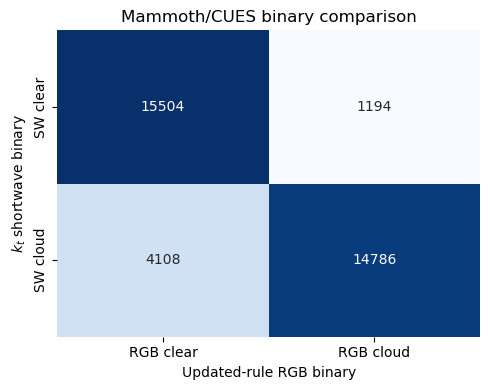

In [3]:
truth, prediction = compare.sw_cloud_binary, compare.rgb_cloud_binary
cm = confusion_matrix(truth, prediction, labels=[0,1])
report = classification_report(truth, prediction, labels=[0,1], target_names=['clear','cloud'], output_dict=True, zero_division=0)
metrics = pd.DataFrame([{
    'n': len(compare), 'accuracy': (truth == prediction).mean(),
    'balanced_accuracy': balanced_accuracy_score(truth, prediction),
    'cohen_kappa': cohen_kappa_score(truth, prediction),
    'macro_f1': f1_score(truth, prediction, average='macro', zero_division=0),
    'weighted_f1': f1_score(truth, prediction, average='weighted', zero_division=0),
    'clear_precision': report['clear']['precision'], 'clear_recall': report['clear']['recall'],
    'clear_f1': report['clear']['f1-score'], 'cloud_precision': report['cloud']['precision'],
    'cloud_recall': report['cloud']['recall'], 'cloud_f1': report['cloud']['f1-score'],
}])
display(metrics.T)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['RGB clear','RGB cloud'], yticklabels=['SW clear','SW cloud'], ax=ax)
ax.set_xlabel('Updated-rule RGB binary'); ax.set_ylabel('$k_t$ shortwave binary')
ax.set_title('Mammoth/CUES binary comparison')
fig.tight_layout(); fig.savefig(OUT/'mammoth_cues_binary_confusion_matrix.png', dpi=200)
plt.show()

## 4. Confusion matrices by UTC hour

Only hours containing unambiguous matched observations are shown. “Overall F1” in each title is macro F1 across the clear and cloud classes for that hour.

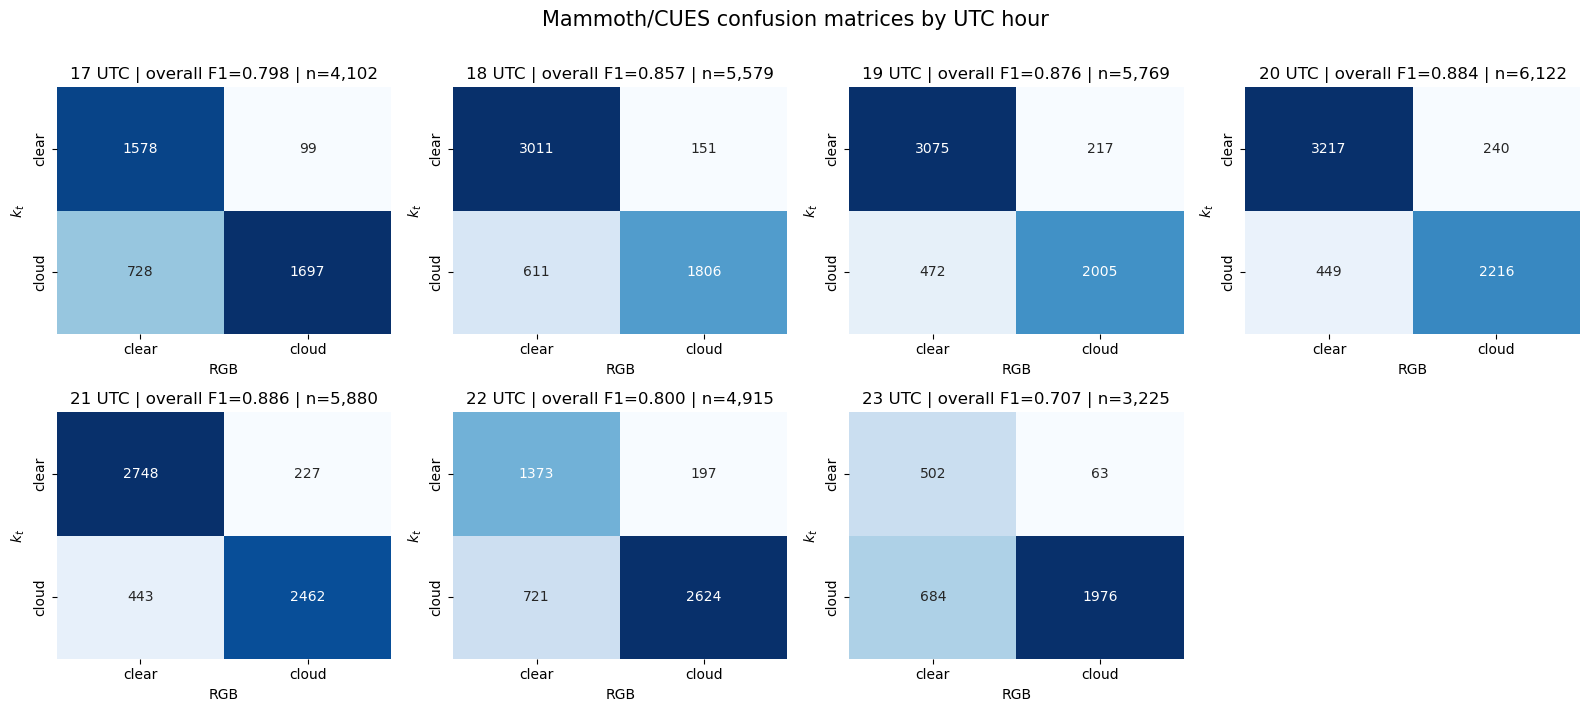

,utc_hour,n,macro_f1
0,17,4102,0.798221
1,18,5579,0.856733
2,19,5769,0.876314
3,20,6122,0.884364
4,21,5880,0.885784
5,22,4915,0.800287
6,23,3225,0.707208


In [4]:
import numpy as np

compare['utc_hour'] = compare.time.dt.hour
hours = sorted(compare.utc_hour.unique())
ncols = 4
nrows = int(np.ceil(len(hours) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
axes = np.atleast_1d(axes).ravel()
hourly_metrics = []
for ax, hour in zip(axes, hours):
    group = compare.loc[compare.utc_hour == hour]
    group_cm = confusion_matrix(group.sw_cloud_binary, group.rgb_cloud_binary, labels=[0,1])
    group_f1 = f1_score(group.sw_cloud_binary, group.rgb_cloud_binary, average='macro', zero_division=0)
    hourly_metrics.append({'utc_hour': hour, 'n': len(group), 'macro_f1': group_f1})
    sns.heatmap(group_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['clear','cloud'], yticklabels=['clear','cloud'])
    ax.set_title(f'{hour:02d} UTC | overall F1={group_f1:.3f} | n={len(group):,}')
    ax.set_xlabel('RGB'); ax.set_ylabel('$k_t$')
for ax in axes[len(hours):]: ax.axis('off')
fig.suptitle('Mammoth/CUES confusion matrices by UTC hour', fontsize=15, y=1.01)
fig.tight_layout(); fig.savefig(OUT/'mammoth_cues_confusion_matrices_by_utc_hour.png', dpi=200, bbox_inches='tight')
plt.show()
hourly_metrics = pd.DataFrame(hourly_metrics)
display(hourly_metrics)

## 5. Confusion matrices by month

Each subplot uses all years for that calendar month. “Overall F1” is the month-specific macro F1 across clear and cloud.

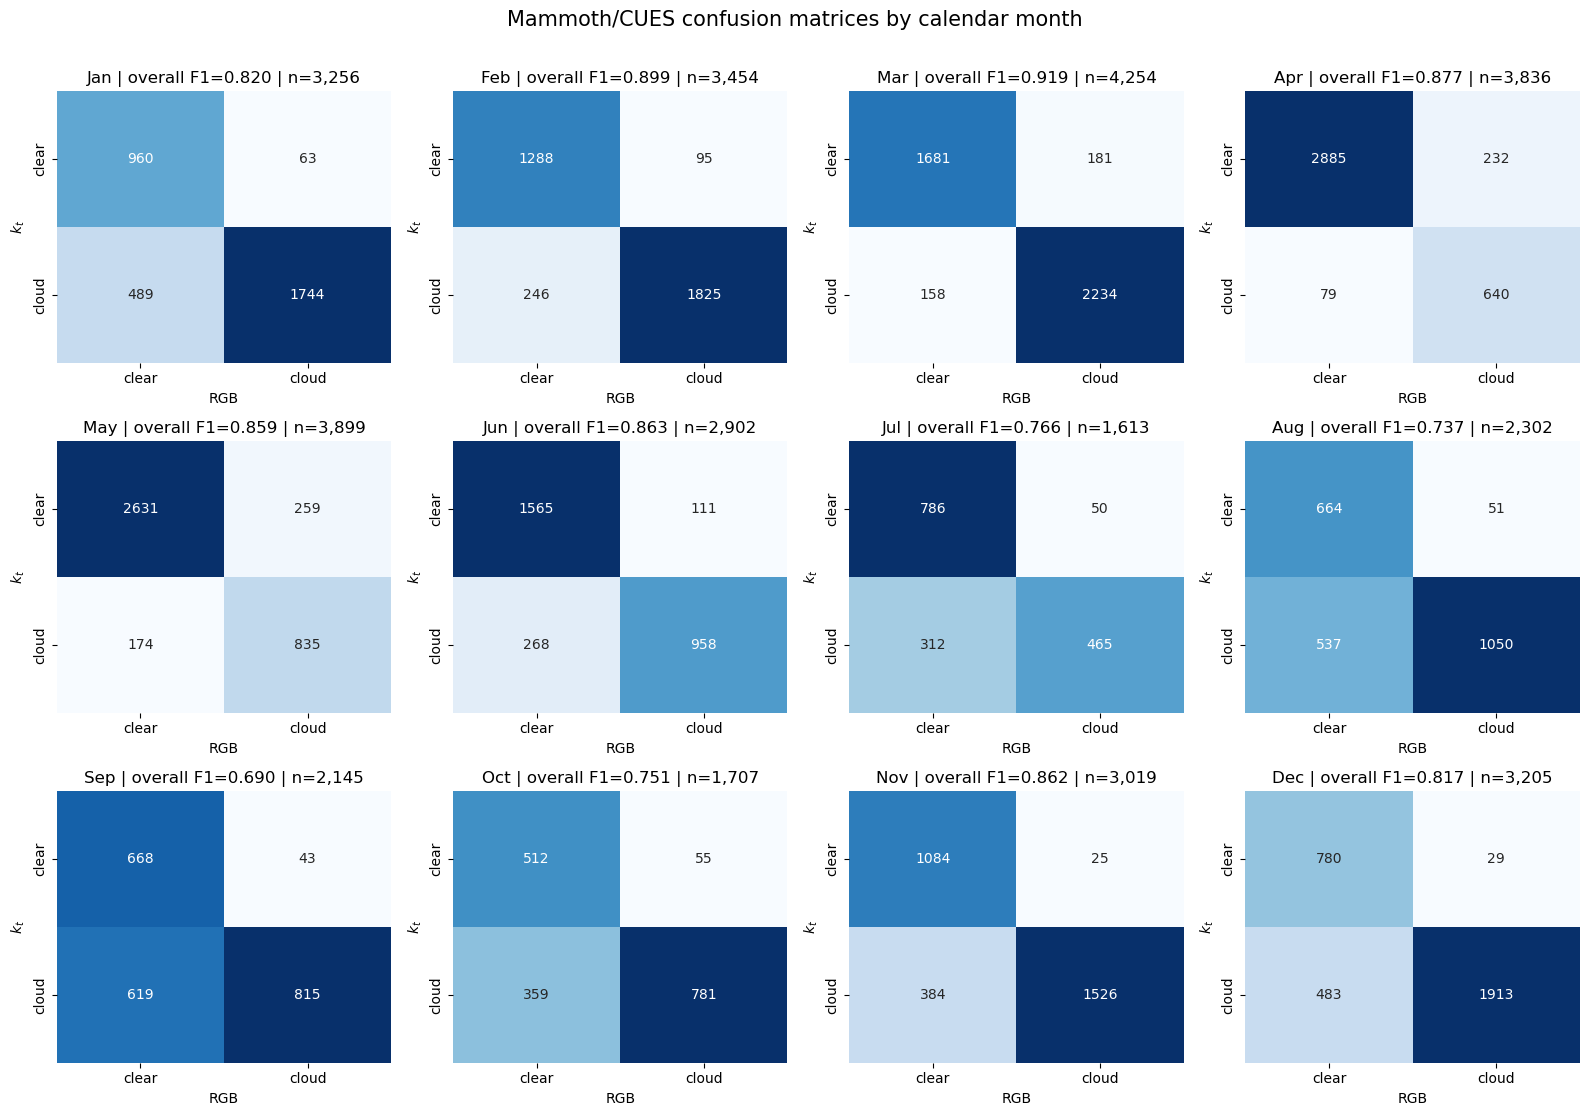

,month,month_name,n,macro_f1
0,1,Jan,3256,0.820033
1,2,Feb,3454,0.898828
2,3,Mar,4254,0.918940
3,4,Apr,3836,0.876691
4,5,May,3899,0.859036
5,6,Jun,2902,0.863425
6,7,Jul,1613,0.766319
7,8,Aug,2302,0.737180
8,9,Sep,2145,0.689919
9,10,Oct,1707,0.751293


In [5]:
compare['month'] = compare.time.dt.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
monthly_metrics = []
for month, ax in enumerate(axes.ravel(), start=1):
    group = compare.loc[compare.month == month]
    group_cm = confusion_matrix(group.sw_cloud_binary, group.rgb_cloud_binary, labels=[0,1])
    group_f1 = f1_score(group.sw_cloud_binary, group.rgb_cloud_binary, average='macro', zero_division=0)
    monthly_metrics.append({'month': month, 'month_name': month_names[month-1], 'n': len(group), 'macro_f1': group_f1})
    sns.heatmap(group_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['clear','cloud'], yticklabels=['clear','cloud'])
    ax.set_title(f'{month_names[month-1]} | overall F1={group_f1:.3f} | n={len(group):,}')
    ax.set_xlabel('RGB'); ax.set_ylabel('$k_t$')
fig.suptitle('Mammoth/CUES confusion matrices by calendar month', fontsize=15, y=1.01)
fig.tight_layout(); fig.savefig(OUT/'mammoth_cues_confusion_matrices_by_month.png', dpi=200, bbox_inches='tight')
plt.show()
monthly_metrics = pd.DataFrame(monthly_metrics)
display(monthly_metrics)

## 6. Confusion matrices by meteorological season

The four panels use the standard meteorological seasons: DJF (December–February), MAM (March–May), JJA (June–August), and SON (September–November). “Overall F1” is the season-specific macro F1 across clear and cloud.

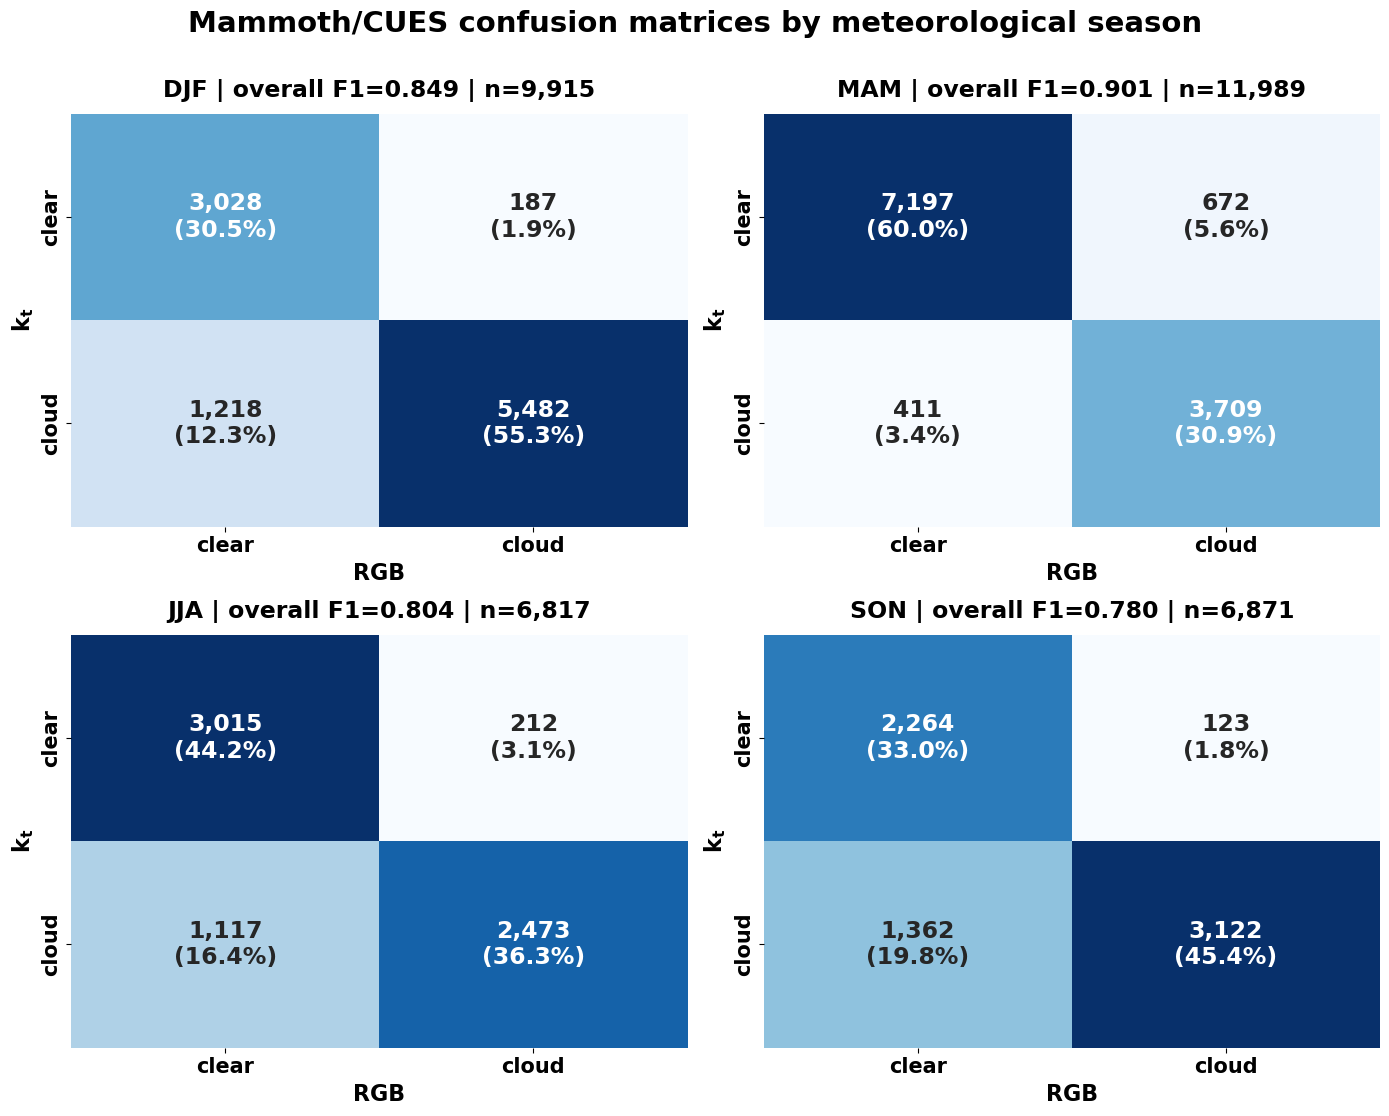

,season,n,accuracy,macro_f1
0,DJF,9915,0.858296,0.849049
1,MAM,11989,0.909667,0.901314
2,JJA,6817,0.805046,0.803806
3,SON,6871,0.783874,0.780451


In [6]:
season_order = ['DJF', 'MAM', 'JJA', 'SON']
season_months = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
}
compare['season'] = compare.time.dt.month.map(
    {month: season for season, months in season_months.items() for month in months}
)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
seasonal_metrics = []
for season, ax in zip(season_order, axes.ravel()):
    group = compare.loc[compare.season == season]
    group_cm = confusion_matrix(
        group.sw_cloud_binary, group.rgb_cloud_binary, labels=[0, 1]
    )
    group_f1 = f1_score(
        group.sw_cloud_binary, group.rgb_cloud_binary,
        average='macro', zero_division=0
    )
    group_accuracy = (group.sw_cloud_binary == group.rgb_cloud_binary).mean()
    seasonal_metrics.append({
        'season': season,
        'n': len(group),
        'accuracy': group_accuracy,
        'macro_f1': group_f1,
    })
    group_annotations = np.array([
        [f'{value:,}\n({value / len(group):.1%})' for value in row]
        for row in group_cm
    ])
    sns.heatmap(
        group_cm, annot=group_annotations, fmt='', cmap='Blues', cbar=False, ax=ax,
        xticklabels=['clear', 'cloud'], yticklabels=['clear', 'cloud'],
        annot_kws={'fontsize': 17, 'fontweight': 'bold'}
    )
    ax.set_title(
        f'{season} | overall F1={group_f1:.3f} | n={len(group):,}',
        fontsize=17, fontweight='bold', pad=12
    )
    ax.set_xlabel('RGB', fontsize=16, fontweight='bold')
    ax.set_ylabel(r'$\mathbf{k_t}$', fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', labelsize=15)
    for tick_label in [*ax.get_xticklabels(), *ax.get_yticklabels()]:
        tick_label.set_fontweight('bold')

fig.suptitle(
    'Mammoth/CUES confusion matrices by meteorological season',
    fontsize=21, fontweight='bold', y=1.01
)
fig.tight_layout()
fig.savefig(
    OUT/'mammoth_cues_confusion_matrices_by_season.png',
    dpi=200, bbox_inches='tight'
)
plt.show()
seasonal_metrics = pd.DataFrame(seasonal_metrics)
display(seasonal_metrics)

## 7. Diagnostic comparison time series

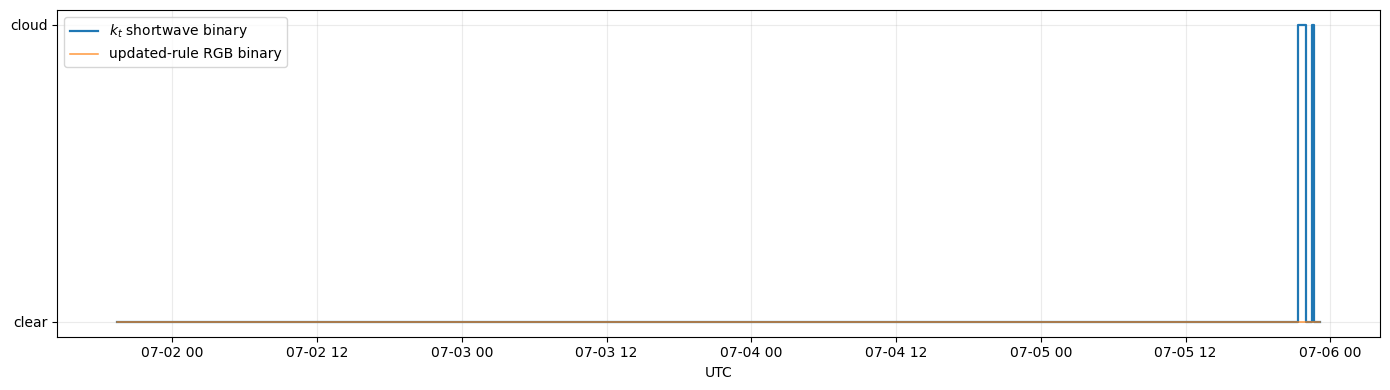

In [7]:
week_start = pd.Timestamp('2024-07-01 15:00')
week = compare.loc[compare.time.between(week_start, week_start + pd.Timedelta(days=7))]
fig, ax = plt.subplots(figsize=(14,4))
ax.step(week.time, week.sw_cloud_binary, where='mid', label='$k_t$ shortwave binary', lw=1.6)
ax.step(week.time, week.rgb_cloud_binary, where='mid', label='updated-rule RGB binary', lw=1.1, alpha=.8)
ax.set_yticks([0,1], ['clear','cloud']); ax.set_xlabel('UTC'); ax.grid(alpha=.25); ax.legend()
fig.tight_layout(); fig.savefig(OUT/'mammoth_cues_binary_week_20240701.png', dpi=200)
plt.show()

## 8. Export the matched comparison and metrics

In [8]:
compare.to_csv(OUT/'mammoth_cues_binary_comparison_all_available.csv', index=False)
metrics.to_csv(OUT/'mammoth_cues_binary_metrics_all_available.csv', index=False)
hourly_metrics.to_csv(OUT/'mammoth_cues_binary_metrics_by_utc_hour.csv', index=False)
monthly_metrics.to_csv(OUT/'mammoth_cues_binary_metrics_by_month.csv', index=False)
seasonal_metrics.to_csv(OUT/'mammoth_cues_binary_metrics_by_season.csv', index=False)
print('Saved comparison outputs to', OUT.resolve())

Saved comparison outputs to /glade/u/home/cdalden/goes_work/analysis/output_13_mammoth_domain_cloud_fraction
